In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import joblib

In [2]:
np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "income": np.random.normal(60000, 15000, n),
    "age": np.random.randint(21, 65, n),
    "employment_years": np.random.randint(0, 40, n),
    "loan_amount": np.random.normal(20000, 8000, n),
    "loan_term": np.random.choice([12,24,36,48,60], n),
    "credit_history_length": np.random.randint(0, 20, n),
    "num_credit_lines": np.random.randint(1, 10, n),
    "num_delinquencies": np.random.randint(0, 5, n),
    "debt_to_income_ratio": np.random.uniform(0.1, 0.6, n),
    "savings_balance": np.random.normal(15000, 7000, n),
})

# rule tạo label
data["approved"] = (
    (data["income"] > 50000) &
    (data["debt_to_income_ratio"] < 0.4) &
    (data["num_delinquencies"] < 2)
).astype(int)

data.head()

,income,age,employment_years,loan_amount,loan_term,credit_history_length,num_credit_lines,num_delinquencies,debt_to_income_ratio,savings_balance,approved
0,67450.712295,50,34,30141.212090,12,13,6,2,0.376134,19619.160194,0
1,57926.035482,51,20,22309.824024,60,3,7,4,0.456181,22391.236108,0
2,69715.328072,58,30,10743.067050,60,9,4,4,0.342269,1870.884005,0
3,82845.447846,31,18,9334.973162,36,2,7,0,0.212284,22772.366029,1
4,56487.699379,55,30,7587.902008,36,6,3,2,0.368639,19615.284727,0


Train/Test Split

In [3]:
X = data.drop("approved", axis=1)
y = data["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train XGBoost

In [5]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9975
ROC AUC: 1.0
Confusion Matrix:
[[331   1]
 [  0  68]]


Feature Importance

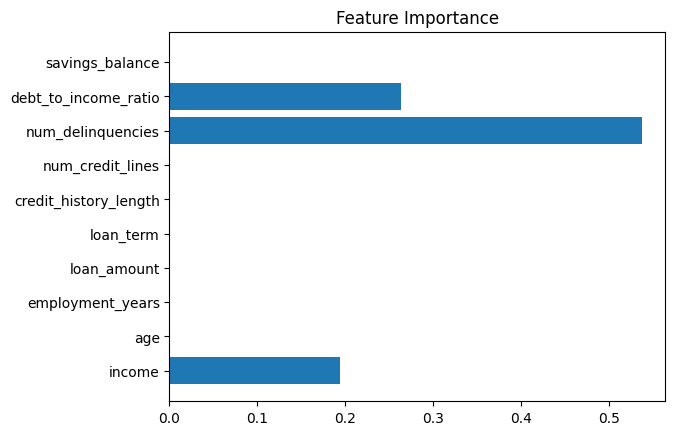

In [7]:
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

Export Model

In [11]:
joblib.dump(model, "credit_model.pkl")

['credit_model.pkl']

In [13]:
import joblib
model = joblib.load("../model/credit_model.pkl")
print("LOADED")

LOADED
